#1. Analyzing sentiments

In [ ]:
from transformers import pipeline

In [ ]:
classificador_sentimento = pipeline('sentiment-analysis', model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
classificador_sentimento('I love this product')

[{'label': 'POSITIVE', 'score': 0.9998788833618164}]

In [ ]:
classificador_sentimento('I hate this product')

[{'label': 'NEGATIVE', 'score': 0.9997544884681702}]

In [ ]:
pip install pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 4.4 MB/s eta 0:00:00


In [ ]:
from pysentimiento import create_analyzer

In [ ]:
modelo_analise_sentimento = create_analyzer(task="sentiment", lang="pt")

config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/562 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/799k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [ ]:
modelo_analise_sentimento.predict('A fritateira é muito bom, além do que eu imaginava. Ela é muit o fácil de usar e de limpar. Super recomendo')

AnalyzerOutput(output=POS, probas={POS: 0.987, NEU: 0.011, NEG: 0.003})

In [ ]:
modelo_analise_sentimento.predict('Após alguns usos o aço começou a oxidar, mas fora isso , o produto cumpre o prometido')

AnalyzerOutput(output=NEU, probas={NEU: 0.954, NEG: 0.027, POS: 0.019})

In [ ]:
import pandas as pd

In [ ]:
dados = pd.read_csv('https://raw.githubusercontent.com/vqrca/hugging_face/main/Dados/resenhas.csv')
dados

,ID,Resenha
0,24,"A fritadeira é sensacional, muito além do que ..."
1,733,"Após usar o produto, achei-o fácil e muito efi..."
2,865,"Muito funcional, prática e moderna."
3,809,"Boa, mas não das melhores pois a frente de vid..."
4,628,Eu comecei a usar e é bem espaçosa. Gostei poi...
5,657,"Usei ela algumas vezes já, muito silenciosa, l..."
6,182,"Superou minhas expectativas, por enquanto tudo..."
7,815,"Chegou no prazo. Amei, é muito linda. Não vejo..."
8,343,"Estou muito satisfeito com a negociação, receb..."
9,624,Lindaaaa amei super indico


In [ ]:
resultados_previsao = modelo_analise_sentimento.predict(dados['Resenha'])

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
resultados_previsao

[AnalyzerOutput(output=POS, probas={POS: 0.989, NEU: 0.009, NEG: 0.002}),
 AnalyzerOutput(output=POS, probas={POS: 0.670, NEU: 0.320, NEG: 0.011}),
 AnalyzerOutput(output=POS, probas={POS: 0.900, NEU: 0.097, NEG: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.731, NEU: 0.259, POS: 0.010}),
 AnalyzerOutput(output=POS, probas={POS: 0.976, NEU: 0.021, NEG: 0.003}),
 AnalyzerOutput(output=POS, probas={POS: 0.956, NEU: 0.037, NEG: 0.007}),
 AnalyzerOutput(output=POS, probas={POS: 0.838, NEU: 0.093, NEG: 0.069}),
 AnalyzerOutput(output=POS, probas={POS: 0.990, NEU: 0.008, NEG: 0.002}),
 AnalyzerOutput(output=POS, probas={POS: 0.961, NEU: 0.036, NEG: 0.003}),
 AnalyzerOutput(output=POS, probas={POS: 0.990, NEU: 0.007, NEG: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.896, NEU: 0.100, POS: 0.004}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.990, NEU: 0.008, POS: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.985, NEU: 0.011, POS: 0.003}),
 AnalyzerOutput(output=NEU, probas={NE

In [ ]:
sentimento = []

for resultado in resultados_previsao:
  sentimento.append(resultado.output)

In [ ]:
sentimento

['POS',
 'POS',
 'POS',
 'NEG',
 'POS',
 'POS',
 'POS',
 'POS',
 'POS',
 'POS',
 'NEG',
 'NEG',
 'NEG',
 'NEU',
 'NEG',
 'NEG',
 'NEG',
 'NEU',
 'NEG',
 'NEG',
 'NEU',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'NEG',
 'POS',
 'POS',
 'NEU',
 'POS',
 'POS']

In [ ]:
dados['Sentimento'] = sentimento

In [ ]:
dados

,ID,Resenha,Sentimento
0,24,"A fritadeira é sensacional, muito além do que ...",POS
1,733,"Após usar o produto, achei-o fácil e muito efi...",POS
2,865,"Muito funcional, prática e moderna.",POS
3,809,"Boa, mas não das melhores pois a frente de vid...",NEG
4,628,Eu comecei a usar e é bem espaçosa. Gostei poi...,POS
5,657,"Usei ela algumas vezes já, muito silenciosa, l...",POS
6,182,"Superou minhas expectativas, por enquanto tudo...",POS
7,815,"Chegou no prazo. Amei, é muito linda. Não vejo...",POS
8,343,"Estou muito satisfeito com a negociação, receb...",POS
9,624,Lindaaaa amei super indico,POS


In [ ]:
import plotly.express as px

df_sentimento = dados.groupby('Sentimento').size().reset_index(name='Contagem')

graf = px.bar(df_sentimento, x='Sentimento', y='Contagem', title='Distribuição de Sentimentos')

graf.show()

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
portuguese_stopwords = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def nuvem_palavras(texto, coluna_texto, sentimento):
  texto_sentimento = texto.query(f"Sentimento == '{sentimento}'")[coluna_texto]
  texto_unido = " ".join(texto_sentimento)

  palavras = texto_unido.split()
  palavras_filtradas = [palavra for palavra in palavras if palavra not in portuguese_stopwords]
  texto_filtrado = " ".join(palavras_filtradas)

  nuvem_palavras = WordCloud(width=800, height=400, max_words=50).generate(texto_filtrado)
  plt.figure(figsize=(10, 5))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()

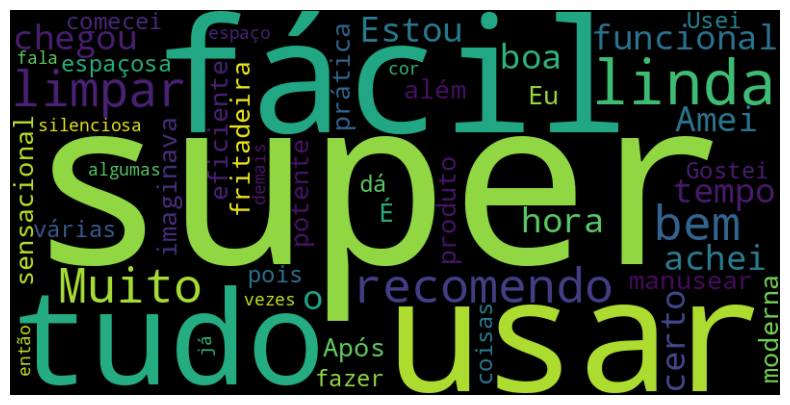

In [ ]:
nuvem_palavras(dados, 'Resenha', 'POS')

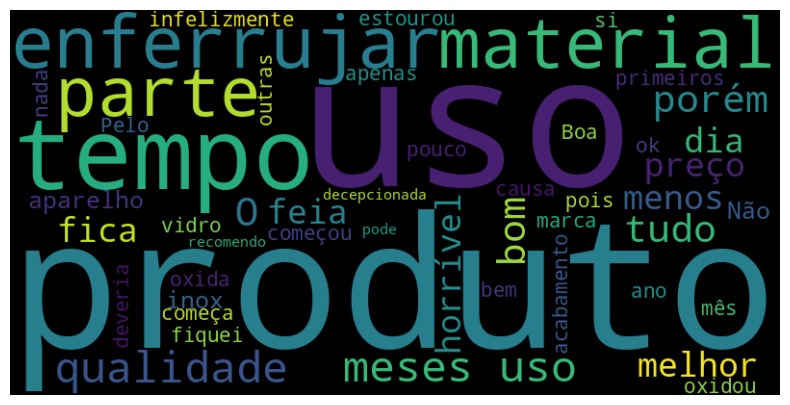

In [ ]:
nuvem_palavras(dados, 'Resenha', 'NEG')

#2. Categorizing products

In [ ]:
from transformers import pipeline

In [ ]:
classificador = pipeline('zero-shot-classification', model='facebook/bart-large-mnli')

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
categorias = ['eletronics', 'food', 'toys', 'books']

In [ ]:
predicao = classificador('''
Latest model of smarthphone with 5G connectivity and 128GB internal storage''', candidate_labels=categorias)

In [ ]:
predicao

{'sequence': '\nLatest model of smarthphone with 5G connectivity and 128GB internal storage',
 'labels': ['eletronics', 'toys', 'food', 'books'],
 'scores': [0.8611087799072266,
  0.05995432287454605,
  0.04200141131877899,
  0.036935560405254364]}

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.38.2 sentencepiece


Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
Using cached transformers-4.38.2-py3-none-any.whl (8.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [ ]:
from liqfit.pipeline import ZeroShotClassificationPipeline
from liqfit.models import T5ForZeroShotClassification
from transformers import T5Tokenizer

model = T5ForZeroShotClassification.from_pretrained('knowledgator/comprehend_it-multilingual-t5-base')
tokenizer = T5Tokenizer.from_pretrained('knowledgator/comprehend_it-multilingual-t5-base')
classifier = ZeroShotClassificationPipeline(model=model, tokenizer=tokenizer,
                                                      hypothesis_template = '{}', encoder_decoder = True)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

You are using a model of type T5 to instantiate a model of type t5. This is not supported for all configurations of models and can yield errors.


...

tokenizer_config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
descricao = ''' Este water gel leve e refrescantes, proporciona hidratação imediata que ajuda aavaliar
o repuxamento e aspereza da pele sensível'''
categorias_candidatas = ['beleza', 'cozinha', 'livros']
resultado = classifier(descricao, categorias_candidatas, multi_label=False)
resultado

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'sequence': ' Este water gel leve e refrescantes, proporciona hidratação imediata que ajuda aavaliar\no repuxamento e aspereza da pele sensível',
 'labels': ['beleza', 'livros', 'cozinha'],
 'scores': [0.9295139312744141, 0.04621047526597977, 0.024275552481412888]}

In [ ]:
import pandas as pd

In [ ]:
resultado = pd.DataFrame(resultado).drop(['sequence'], axis=1)
resultado

,labels,scores
0,beleza,0.929514
1,livros,0.046210
2,cozinha,0.024276


In [ ]:
descricao = '''
A fritadeira eletrica sem óleo start fry da elgin possui um design unico, capacidade para até 3,5 litros,
potência de 1400w e revestimento antiaderente. Seu sistema de circulação de ar ultrarapido frita e economiza
energia. Sua grelha de fritura é removivel e super fácil de limpar. Ela conta com uma proteção contra
super aquecimento. Possui controle de temperatura de 80°c a 200°c que permite você programar a temperatura
de preparo para cada tipo de alimento,timer para até 60 minutos com aviso sonoro e desligamento automático,
assim você pode deixar preparando sua refeição enquanto realiza outras tarefas.
'''

categorias_candidatas = ['beleza', 'cozinha', 'livros']
resultado = classifier(descricao, categorias_candidatas, multi_label=False)
resultado = pd.DataFrame(resultado).drop(['sequence'], axis=1)
resultado

,labels,scores
0,cozinha,0.718628
1,beleza,0.235084
2,livros,0.046288


In [ ]:
dados = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/hugging_face/main/Dados/descricoes_produtos.csv')
dados

,Descrição
0,Liquidificador de alta potência com jarra de v...
1,"Forno Micro-ondas de 20 litros, com menu desco..."
2,Máquina de café espresso com reservatório de á...
3,Torradeira com capacidade para quatro fatias e...
4,"Panela elétrica multifuncional que cozinha, as..."
5,Smartphone com 128GB de armazenamento e câmera...
6,"Smartwatch monitoramento de passos, frequência..."
7,Notebook gamer com placa de vídeo potente e te...
8,"Smartphone com tela super retina XDR de 6,7 po..."
9,Câmera digital com zoom óptico de 20x e vídeos...


In [ ]:
categorias = ['eletrodomésticos', 'eletrônicos', 'beleza', 'brinquedos']

def categorizar(descricao):
  resultado = classifier(descricao, categorias, multi_label=False)
  categoria_max = max(zip(resultado['labels'], resultado['scores']), key=lambda x: x[1])[0]
  return categoria_max

dados['Categoria'] = dados['Descrição'].apply(categorizar)

In [ ]:
dados

,Descrição,Categoria
0,Liquidificador de alta potência com jarra de v...,eletrodomésticos
1,"Forno Micro-ondas de 20 litros, com menu desco...",eletrodomésticos
2,Máquina de café espresso com reservatório de á...,eletrodomésticos
3,Torradeira com capacidade para quatro fatias e...,eletrodomésticos
4,"Panela elétrica multifuncional que cozinha, as...",eletrodomésticos
5,Smartphone com 128GB de armazenamento e câmera...,eletrônicos
6,"Smartwatch monitoramento de passos, frequência...",eletrônicos
7,Notebook gamer com placa de vídeo potente e te...,eletrônicos
8,"Smartphone com tela super retina XDR de 6,7 po...",eletrônicos
9,Câmera digital com zoom óptico de 20x e vídeos...,eletrônicos
